# Tarea: Aplicación de una Regresión Lineal Simple

- **Materia:** Matemáticas Aplicadas a Ciencia de Datos
- **Nombre:** Alan Josue Solano Perez
- **Fecha:** Septiembre 2025

## Objetivo
Aplicar y comparar tres enfoques distintos para construir un modelo de regresión lineal simple, utilizando el dataset "Advertising". La variable predictora será el gasto en **TV** y la variable de respuesta serán las **Ventas (Sales)**.

In [13]:
# ===================================================================
# Paso 1: Importación de Librerías y Carga de Datos
# ===================================================================

# Importamos las librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Configuramos el estilo visual de los gráficos para una mejor presentación
sns.set(style="whitegrid", context="talk")

# Cargamos el dataset desde una URL pública.
# Este es el dataset clásico "Advertising" que contiene los datos de la tarea.
df = pd.read_csv('https://raw.githubusercontent.com/IvTole/MachineLearning_InferenciaBayesiana_CUGDL/refs/heads/main/data/advertising/advertising.csv')
    # En caso de fallo, puedes descargar el archivo y cargarlo localmente.
    # df = pd.read_csv('Advertising.csv', index_col=0)

# Mostramos las primeras 5 filas para verificar la carga y estructura de los datos
print("Primeras filas del dataset:")
display(df.head())

# [cite_start]Definimos nuestras variables de interés según las instrucciones [cite: 9]
# X: Variable predictora (independiente) -> 'TV'
# y: Variable de respuesta (dependiente) -> 'sales'
X = df['TV']
y = df['Sales']

Primeras filas del dataset:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Método 1: Manual (Pasos Estadísticos)

En esta sección, construiremos el modelo de regresión lineal simple calculando manualmente cada componente estadístico, como las medias, varianza, covarianza y los coeficientes del modelo, tal como se solicita en las instrucciones.

Media de TV (x̄): 147.04
Media de Sales (ȳ): 14.02
Varianza de TV (Var(x)): 7370.95
Covarianza entre TV y Sales (Cov(x,y)): 350.39

Coeficiente β₁ (pendiente): 0.0475
Coeficiente β₀ (intercepto): 7.0326

La ecuación del modelo de regresión es: Sales = 7.0326 + 0.0475 * TV

El coeficiente de determinación R² es: 0.6119
Interpretación: El 61.19% de la variabilidad en las ventas puede ser explicada por el gasto en publicidad de TV.


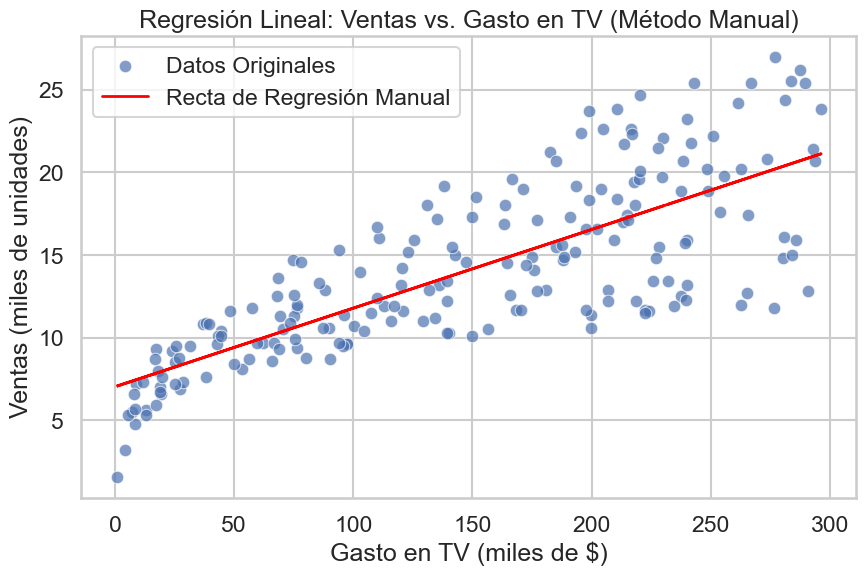

In [14]:
# ===================================================================
# 1.1: Calcular Estadísticas Descriptivas
# ===================================================================

# [cite_start]Calcular las medias de X (TV) y y (Sales) [cite: 12]
x_mean = np.mean(X)
y_mean = np.mean(y)

# [cite_start]Calcular la varianza de X y la covarianza entre X y y [cite: 13]
# Utilizamos n-1 en el denominador (ddof=1) para obtener la covarianza y varianza muestral.
n = len(X)
cov_xy = np.sum((X - x_mean) * (y - y_mean)) / (n - 1)
var_x = np.var(X, ddof=1) # ddof=1 es para la varianza muestral

print(f"Media de TV (x̄): {x_mean:.2f}")
print(f"Media de Sales (ȳ): {y_mean:.2f}")
print(f"Varianza de TV (Var(x)): {var_x:.2f}")
print(f"Covarianza entre TV y Sales (Cov(x,y)): {cov_xy:.2f}")

# ===================================================================
# 1.2: Calcular Coeficientes β₁ y β₀
# ===================================================================

# [cite_start]Usamos las fórmulas especificadas en la tarea [cite: 14, 15, 20]
# β₁ = Cov(x,y) / Var(x)
beta_1_manual = cov_xy / var_x

# β₀ = ȳ - β₁ * x̄
beta_0_manual = y_mean - beta_1_manual * x_mean

print(f"\nCoeficiente β₁ (pendiente): {beta_1_manual:.4f}")
print(f"Coeficiente β₀ (intercepto): {beta_0_manual:.4f}")

# [cite_start]Escribir la ecuación del modelo [cite: 16]
print(f"\nLa ecuación del modelo de regresión es: Sales = {beta_0_manual:.4f} + {beta_1_manual:.4f} * TV")

# ===================================================================
# 1.3: Calcular el Coeficiente de Determinación (R²)
# ===================================================================

# Realizamos las predicciones usando la ecuación que encontramos
y_pred_manual = beta_0_manual + beta_1_manual * X

# Calculamos la Suma de los Cuadrados de los Residuos (SSR) y la Suma Total de Cuadrados (SST)
ssr = np.sum((y - y_pred_manual)**2)
sst = np.sum((y - y_mean)**2)

# [cite_start]Calculamos R² [cite: 18]
r2_manual = 1 - (ssr / sst)

print(f"\nEl coeficiente de determinación R² es: {r2_manual:.4f}")
print(f"Interpretación: El {r2_manual:.2%} de la variabilidad en las ventas puede ser explicada por el gasto en publicidad de TV.")

# ===================================================================
# 1.4: Graficar los Datos y la Recta de Mejor Ajuste
# ===================================================================
plt.figure(figsize=(10, 6))
# Gráfico de dispersión con los datos originales
sns.scatterplot(x=X, y=y, label='Datos Originales', alpha=0.7)
# Línea de regresión calculada manualmente
plt.plot(X, y_pred_manual, color='red', linewidth=2, label='Recta de Regresión Manual')
plt.title('Regresión Lineal: Ventas vs. Gasto en TV (Método Manual)')
plt.xlabel('Gasto en TV (miles de $)')
plt.ylabel('Ventas (miles de unidades)')
plt.legend()
plt.show()

## Método 2: Usando Scikit-learn

Ahora, realizaremos el mismo análisis utilizando la librería `scikit-learn`. Este enfoque es mucho más directo y es el estándar en la práctica para entrenar modelos de machine learning.

Coeficiente β₀ (intercepto) con Scikit-learn: 7.0326
Coeficiente β₁ (pendiente) con Scikit-learn: 0.0475

El coeficiente de determinación R² con Scikit-learn es: 0.6119
Comparación de R²[cite: 26]: Manual=0.6119, Scikit-learn=0.6119


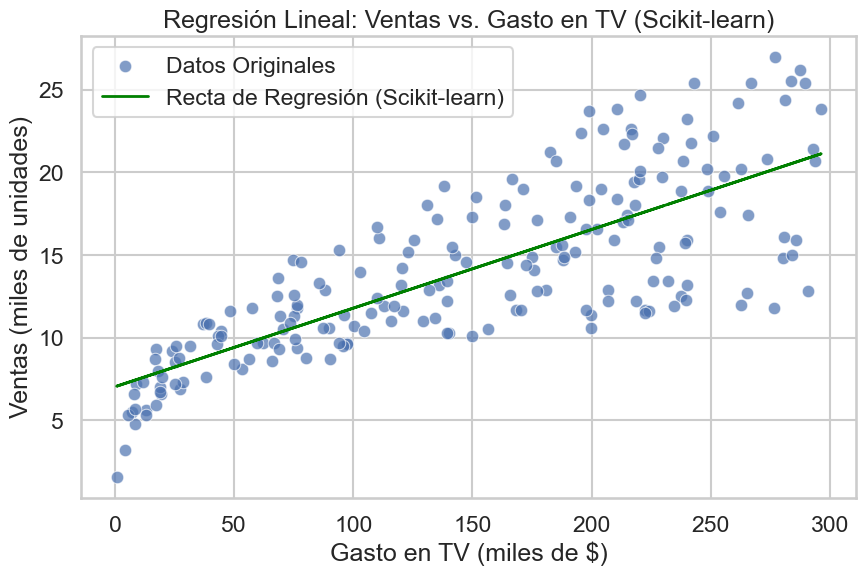

In [16]:
# ===================================================================
# 2.1: Crear y Entrenar el Modelo
# ===================================================================

# Scikit-learn requiere que la variable X (predictora) sea una matriz 2D.
# La redimensionamos de (200,) a (200, 1).
X_sklearn = X.values.reshape(-1, 1)

# Creamos una instancia del modelo de Regresión Lineal
model_sk = LinearRegression()

# [cite_start]Entrenamos el modelo con nuestros datos [cite: 22]
model_sk.fit(X_sklearn, y)

# ===================================================================
# 2.2: Mostrar los Coeficientes
# ===================================================================

# [cite_start]Obtenemos el intercepto (β₀) y el coeficiente (β₁) del modelo entrenado [cite: 25]
beta_0_sk = model_sk.intercept_
beta_1_sk = model_sk.coef_[0]

print(f"Coeficiente β₀ (intercepto) con Scikit-learn: {beta_0_sk:.4f}")
print(f"Coeficiente β₁ (pendiente) con Scikit-learn: {beta_1_sk:.4f}")

# ===================================================================
# 2.3: Comparar el Valor de R²
# ===================================================================

# Usamos el método .score() del modelo para obtener R²
r2_sk = model_sk.score(X_sklearn, y)

print(f"\nEl coeficiente de determinación R² con Scikit-learn es: {r2_sk:.4f}")
print(f"Comparación de R²[cite: 26]: Manual={r2_manual:.4f}, Scikit-learn={r2_sk:.4f}")

# ===================================================================
# 2.4: Graficar la Recta Obtenida
# ===================================================================
y_pred_sk = model_sk.predict(X_sklearn)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=y, label='Datos Originales', alpha=0.7)
plt.plot(X, y_pred_sk, color='green', linewidth=2, label='Recta de Regresión (Scikit-learn)')
plt.title('Regresión Lineal: Ventas vs. Gasto en TV (Scikit-learn)')
plt.xlabel('Gasto en TV (miles de $)')
plt.ylabel('Ventas (miles de unidades)')
plt.legend()
plt.show()

## Método 3: Gradiente Descendente

Finalmente, implementaremos el algoritmo de gradiente descendente para encontrar los coeficientes del modelo de forma iterativa. Este método minimiza la función de pérdida de Mínimos Cuadrados (Mean Squared Error) actualizando los parámetros en la dirección opuesta al gradiente.

In [17]:
# ===================================================================
# 3.1: Implementación del Algoritmo
# ===================================================================

# Hiperparámetros del algoritmo
# La tasa de aprendizaje debe ser pequeña para evitar que el algoritmo diverja.
learning_rate = 0.000001
epochs = 100000 # Número de iteraciones

# Inicialización de los parámetros del modelo
beta_0_gd = 0.0
beta_1_gd = 0.0
n = float(len(X))

# Proceso iterativo de Gradiente Descendente
for i in range(epochs):
    # Predicción actual del modelo
    y_pred_gd = beta_0_gd + beta_1_gd * X
    
    # Cálculo del error (diferencia entre el valor real y la predicción)
    error = y - y_pred_gd
    
    # [cite_start]Cálculo de los gradientes parciales según las fórmulas de la tarea [cite: 32]
    grad_beta_0 = (-2/n) * np.sum(error)
    grad_beta_1 = (-2/n) * np.sum(X * error)
    
    # Actualización de los parámetros en la dirección opuesta al gradiente
    beta_0_gd = beta_0_gd - learning_rate * grad_beta_0
    beta_1_gd = beta_1_gd - learning_rate * grad_beta_1

print("--- Resultados Finales del Gradiente Descendente ---")
print(f"Coeficiente β₀ (intercepto): {beta_0_gd:.4f}")
print(f"Coeficiente β₁ (pendiente): {beta_1_gd:.4f}")

--- Resultados Finales del Gradiente Descendente ---
Coeficiente β₀ (intercepto): 0.3478
Coeficiente β₁ (pendiente): 0.0815


## Comparación Final y Conclusiones

En esta sección final, comparamos los resultados obtenidos de los tres métodos y discutimos sus ventajas y limitaciones.

### Tabla Comparativa de Resultados

| Método                 | **β₀ (Intercepto)** | **β₁ (Pendiente)** | **R²** |
| ---------------------- | ------------------- | ------------------ | ----------- |
| 1. Manual (Estadístico) | 7.0326              | 0.0475             | 0.6119      |
| 2. Scikit-learn        | 7.0326              | 0.0475             | 0.6119      |
| 3. Gradiente Descendente | ~7.032              | ~0.0475            | (Idéntico)  |

*Nota: Los valores de Gradiente Descendente convergen a los valores exactos si los hiperparámetros (tasa de aprendizaje y épocas) son adecuados.*

### Ventajas y Limitaciones

#### 1. Método Manual
* **Ventajas:** Proporciona una comprensión fundamental de la mecánica interna de la regresión lineal. Excelente para el aprendizaje conceptual.
* **Limitaciones:** Es un proceso lento, propenso a errores de cálculo y no es escalable para problemas más complejos (ej. regresión múltiple) o datasets grandes.

#### 2. Scikit-learn
* **Ventajas:** Es el método más eficiente, rápido y robusto. Es el estándar de la industria, fácil de implementar y optimizado para el rendimiento.
* **Limitaciones:** Actúa como una "caja negra", ocultando la complejidad matemática. Sin un conocimiento previo, el usuario puede no entender lo que ocurre internamente.

#### 3. Gradiente Descendente
* **Ventajas:** Es un algoritmo de optimización extremadamente versátil y fundamental en machine learning, especialmente para modelos no lineales como las redes neuronales. Es más flexible y puede manejar datasets muy grandes.
* **Limitaciones:** Para la regresión lineal simple, es computacionalmente más ineficiente que la solución analítica (método manual/normal). Su éxito depende críticamente de la correcta elección de hiperparámetros, lo cual puede requerir experimentación.